# Credit Scorecard Development
## Notebook 1 — Exploratory Data Analysis

This notebook explores the credit application dataset to understand:
- Portfolio composition and demographics
- Missing value patterns
- Feature distributions vs default status
- Correlation structure

**Dataset:** Synthetic credit application data (n = 15,000) simulating Thai commercial bank lending.

In [18]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import load_credit_data

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_style('whitegrid')

df = load_credit_data()
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (150000, 9)


,default,credit_utilization,age,debt_to_income,annual_income,num_credit_accounts,num_real_estate_loans,num_dependents,num_delinquencies
1,1,0.766127,45,0.802982,109440.0,13,6,2.0,2
2,0,0.957151,40,0.121876,31200.0,4,0,1.0,0
3,0,0.658180,38,0.085113,36504.0,2,0,0.0,2
4,0,0.233810,30,0.036050,39600.0,5,0,0.0,0
5,0,0.907239,49,0.024926,763056.0,7,1,0.0,1


## 1. Basic Statistics & Missing Values

In [19]:
print('=== Data Types & Non-null Counts ===')
print(df.info())

print('\n=== Descriptive Statistics ===')
df.describe().round(2)

=== Data Types & Non-null Counts ===
<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   default                150000 non-null  int64  
 1   credit_utilization     150000 non-null  float64
 2   age                    150000 non-null  int64  
 3   debt_to_income         150000 non-null  float64
 4   annual_income          120269 non-null  float64
 5   num_credit_accounts    150000 non-null  int64  
 6   num_real_estate_loans  150000 non-null  int64  
 7   num_dependents         146076 non-null  float64
 8   num_delinquencies      150000 non-null  int64  
dtypes: float64(4), int64(5)
memory usage: 11.4 MB
None

=== Descriptive Statistics ===


,default,credit_utilization,age,debt_to_income,annual_income,num_credit_accounts,num_real_estate_loans,num_dependents,num_delinquencies
count,150000.00,150000.00,150000.00,150000.00,120269.00,150000.00,150000.00,146076.00,150000.00
mean,0.07,0.32,52.30,2.26,79699.88,8.45,1.02,0.76,0.42
std,0.25,0.35,14.77,3.84,125125.12,5.15,1.13,1.12,1.15
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.03,41.00,0.18,40800.00,5.00,0.00,0.00,0.00
50%,0.00,0.15,52.00,0.37,64800.00,8.00,1.00,0.00,0.00
75%,0.00,0.56,63.00,0.87,98988.00,11.00,2.00,1.00,0.00
max,1.00,1.00,109.00,10.00,12000000.00,58.00,54.00,20.00,10.00


=== Missing Value Summary ===
                missing_count  missing_pct
annual_income           29731        19.82
num_dependents           3924         2.62


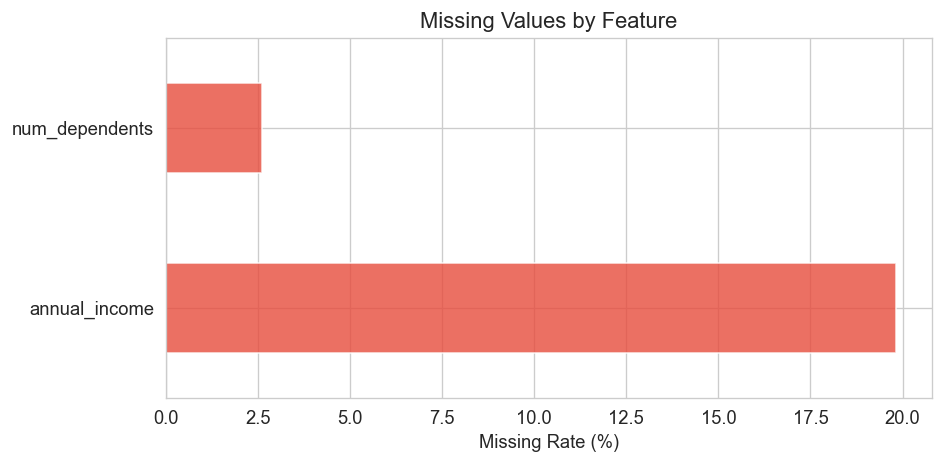

In [20]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0]

print('=== Missing Value Summary ===')
print(missing_df)

fig, ax = plt.subplots(figsize=(8, 4))
missing_df['missing_pct'].plot(kind='barh', ax=ax, color='#e74c3c', alpha=0.8)
ax.set_xlabel('Missing Rate (%)')
ax.set_title('Missing Values by Feature')
plt.tight_layout()
plt.savefig('../plots/01_missing_values.png', bbox_inches='tight')
plt.show()

## 2. Default Rate Overview

Overall Default Rate: 6.68%
Defaults: 10,026  |  Non-defaults: 139,974


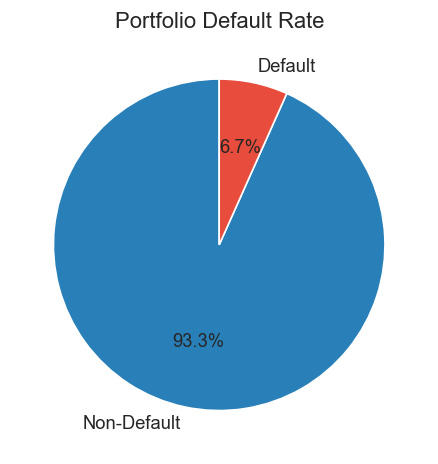

In [21]:
default_rate = df['default'].mean()
print(f'Overall Default Rate: {default_rate:.2%}')
print(f'Defaults: {df["default"].sum():,}  |  Non-defaults: {(1-df["default"]).sum():,}')

fig, ax = plt.subplots(figsize=(5, 4))
labels = ['Non-Default', 'Default']
sizes = [1 - default_rate, default_rate]
colors = ['#2980b9', '#e74c3c']
ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax.set_title('Portfolio Default Rate')
plt.tight_layout()
plt.savefig('../plots/01_default_rate.png', bbox_inches='tight')
plt.show()

## 3. Feature Distributions by Default Status

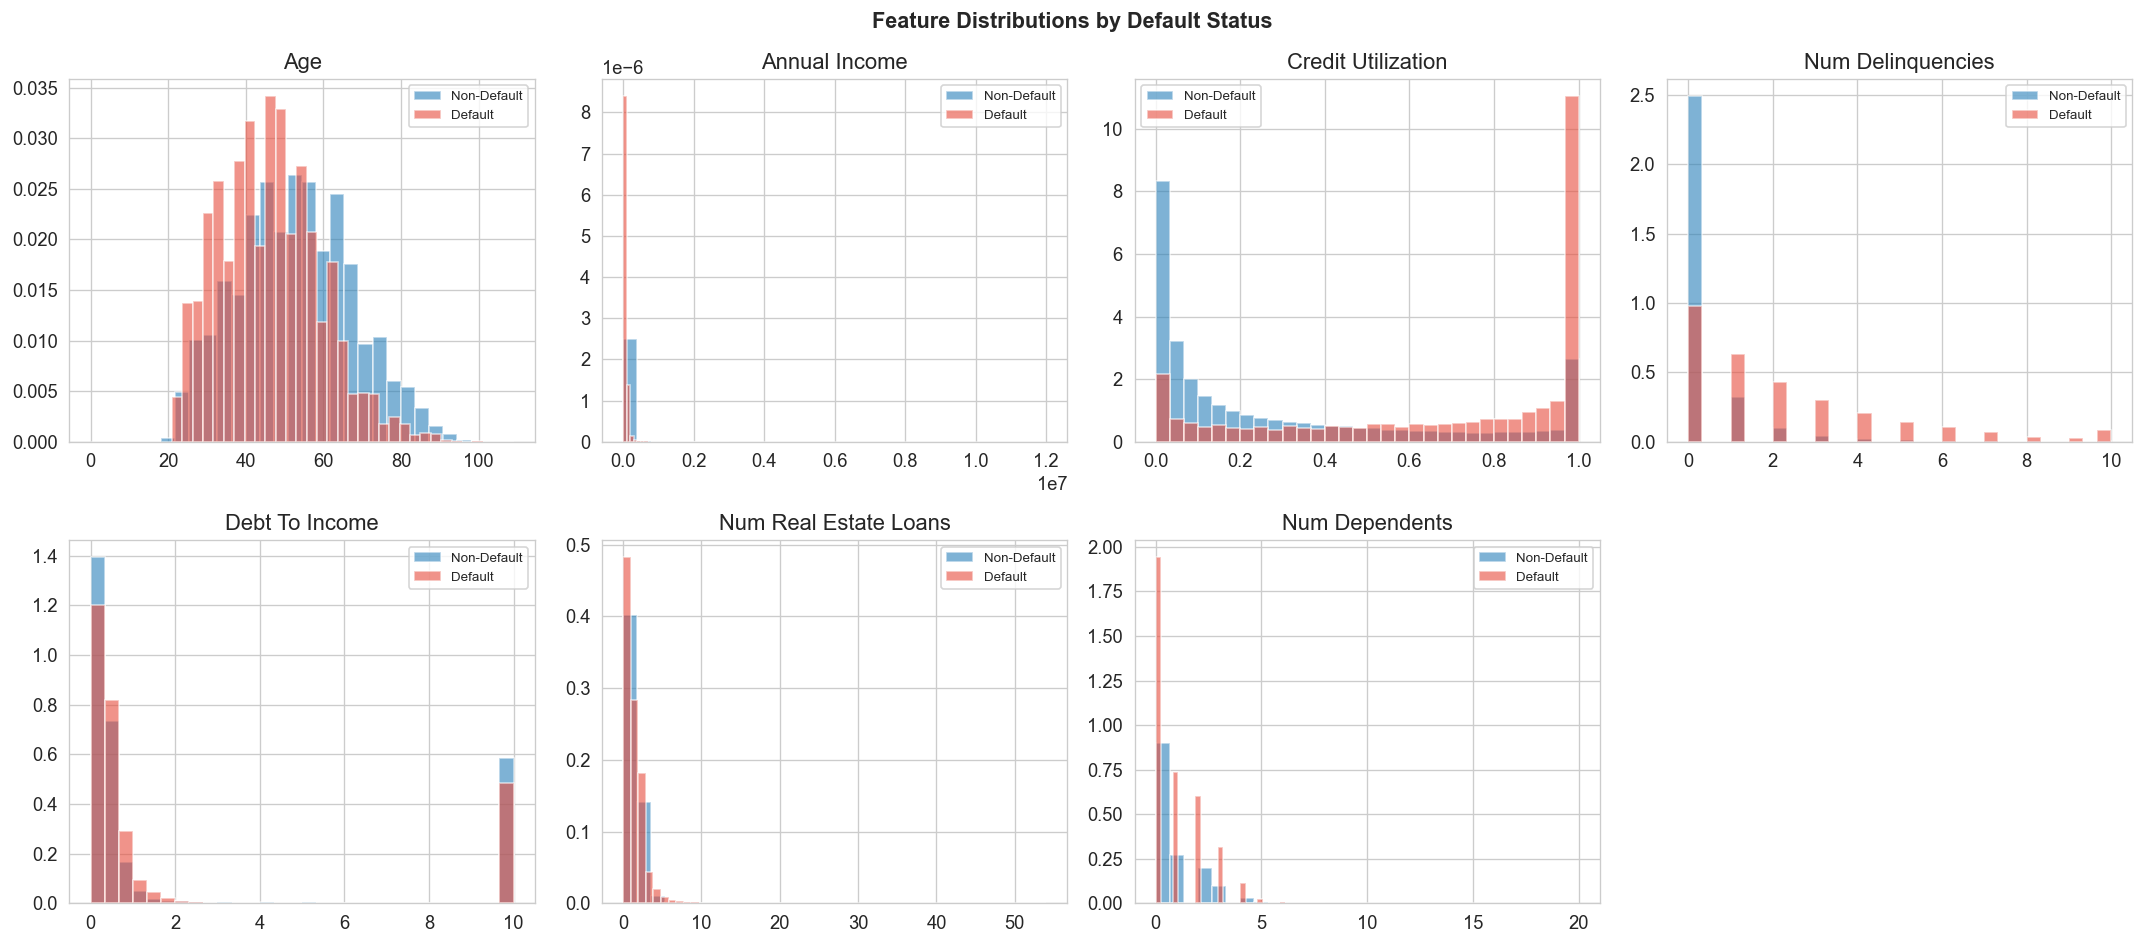

In [22]:
features = ['age', 'annual_income', 'credit_utilization', 'num_delinquencies',
            'debt_to_income', 'num_real_estate_loans', 'num_dependents', 'num_credit_accounts']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    ax = axes[i]
    for label, color in [(0, '#2980b9'), (1, '#e74c3c')]:
        subset = df[df['default'] == label][feat].dropna()
        ax.hist(subset, bins=30, alpha=0.6, color=color,
                label='Non-Default' if label == 0 else 'Default', density=True)
    ax.set_title(feat.replace('_', ' ').title())
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Feature Distributions by Default Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/01_feature_distributions.png', bbox_inches='tight')
plt.show()

## 4. Default Rate by Feature Decile

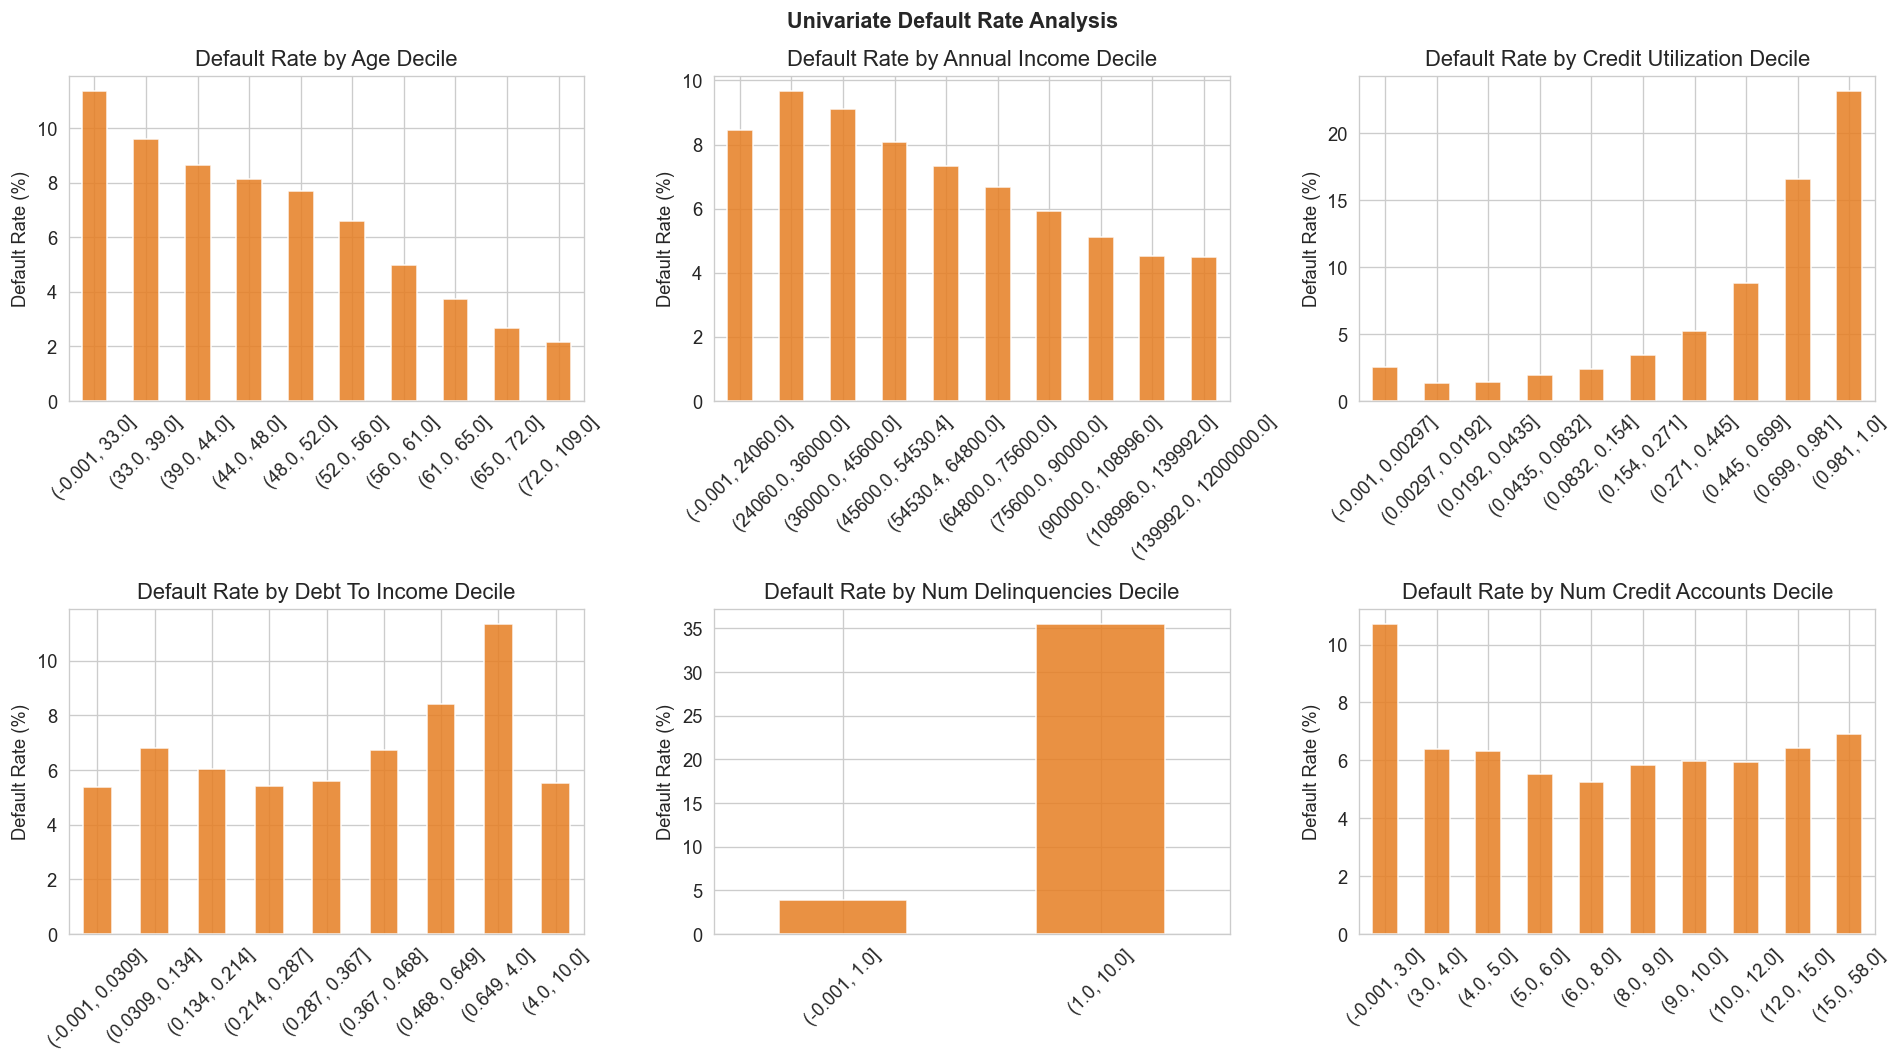

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

cont_features = ['age', 'annual_income', 'credit_utilization',
                 'debt_to_income', 'num_delinquencies', 'num_credit_accounts']

for i, feat in enumerate(cont_features):
    tmp = df[[feat, 'default']].dropna()
    tmp['decile'] = pd.qcut(tmp[feat], q=10, duplicates='drop')
    dr = tmp.groupby('decile', observed=True)['default'].mean() * 100
    dr.plot(kind='bar', ax=axes[i], color='#e67e22', alpha=0.85, edgecolor='white')
    axes[i].set_title(f'Default Rate by {feat.replace("_"," ").title()} Decile')
    axes[i].set_ylabel('Default Rate (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Univariate Default Rate Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/01_default_rate_by_decile.png', bbox_inches='tight')
plt.show()

## 5. Correlation Heatmap

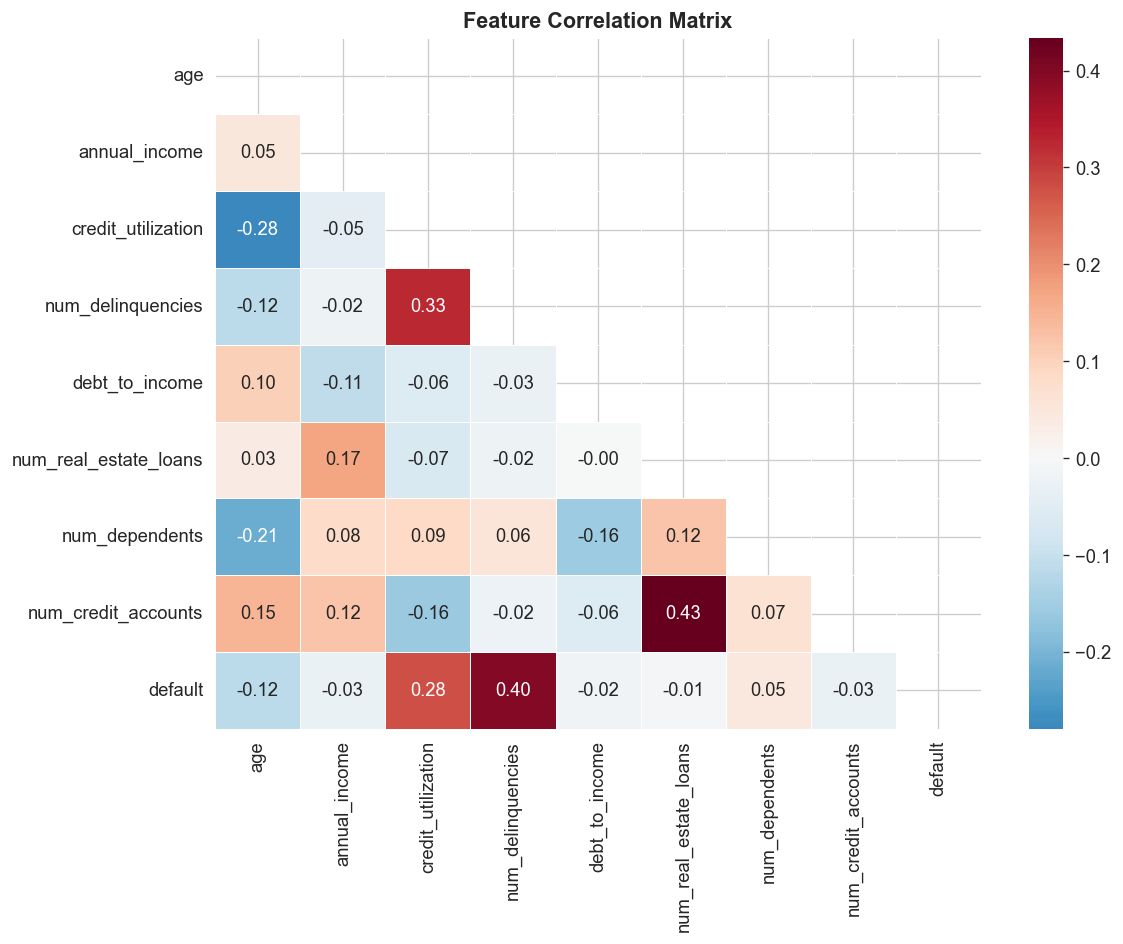


=== Correlation with Default (sorted) ===
num_delinquencies        0.3967
credit_utilization       0.2781
age                     -0.1154
num_dependents           0.0460
num_credit_accounts     -0.0297
annual_income           -0.0265
debt_to_income          -0.0181
num_real_estate_loans   -0.0070
Name: default, dtype: float64


In [24]:
corr = df[features + ['default']].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/01_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print('\n=== Correlation with Default (sorted) ===')
print(corr['default'].drop('default').sort_values(key=abs, ascending=False).round(4))